In [1]:
# notebooks/01_data_preparation.ipynb
# или src/data/preprocess.py

import pandas as pd
import numpy as np
import ast
from sklearn.model_selection import train_test_split


In [3]:
df = pd.read_csv('../data/raw/full_problems.csv')

In [4]:
# 2. Анализ датасета
print(f"Shape: {df.shape}")
print(f"Columns: {df.columns}")
print(f"Missing values:\n{df.isnull().sum()}")
print(f"Target distribution:\n{df['rating'].describe()}")


Shape: (1500, 7)
Columns: Index(['contestId', 'index', 'name', 'rating', 'tags', 'solvedCount',
       'statement'],
      dtype='object')
Missing values:
contestId       0
index           0
name            0
rating          0
tags            0
solvedCount     0
statement      31
dtype: int64
Target distribution:
count    1500.000000
mean     1886.466667
std       828.380544
min       800.000000
25%      1100.000000
50%      1800.000000
75%      2500.000000
max      3500.000000
Name: rating, dtype: float64


In [5]:
df.head(10)

,contestId,index,name,rating,tags,solvedCount,statement
0,2218,G,"The 67th Iteration of ""Counting is Fun""",1800,"['implementation', 'math']",3350,"Macaque has taken you to his habitat, shown yo..."
1,2218,F,The 67th Tree Problem,1500,"['constructive algorithms', 'implementation', ...",6830,Now that PMOI season is over (Cloud emerged vi...
2,2218,E,The 67th XOR Problem,1200,"['binary search', 'bitmasks', 'brute force']",13308,The PMOI wasn't even that awful - word on the ...
3,2218,D,The 67th OEIS Problem,1100,"['constructive algorithms', 'greedy', 'math', ...",17556,"Macaque, being a terrible problemsetter, decid..."
4,2218,C,The 67th Permutation Problem,800,"['constructive algorithms', 'greedy', 'math']",25230,"Upon arriving at school, Macaque was rather br..."
5,2218,B,The 67th 6-7 Integer Problem,800,"['greedy', 'math']",31930,"So, Macaque has passed his first challenge (an..."
6,2218,A,The 67th Integer Problem,800,"['brute force', 'games', 'implementation', 'ma...",32964,"Welcome to the New World, O Esteemed Earthly V..."
7,2217,H,Closer,2800,"['dfs and similar', 'dp', 'trees']",176,"At your networking event, there are $$$n$$$ de..."
8,2217,G,Down the Pivot,2600,"['combinatorics', 'dp', 'math', 'trees']",304,Consider binary trees where each node has at m...
9,2217,F,Interval Game,2300,"['bitmasks', 'combinatorics', 'constructive al...",642,Alice and Bob are playing a game involving two...


In [8]:
# 3. Очистка
# - Удалить дубликаты (по contestId+index)
df = df.drop_duplicates(subset=['contestId', 'index'])

# - Проверить пропуски в target и если отсутствует текст задачи
df = df.dropna(subset=['rating', 'statement'])

# - Обработать tags (список -> one-hot или количество)
df['tags_list'] = df['tags'].apply(ast.literal_eval)
df['n_tags'] = df['tags_list'].apply(len)
df['top_tag'] = df['tags_list'].apply(lambda x: x[0] if x else 'unknown')



In [9]:
# 4. Feature engineering
# Извлечь фичи из statement (длина, кол-во формул и т.д.)
df['statement_length'] = df['statement'].str.len()
df['statement_words'] = df['statement'].str.split().str.len()
df['has_math'] = df['statement'].str.contains(r'\$.*\$', regex=True).astype(int)

# Из названия задачи (длина, заглавные буквы)
df['name_length'] = df['name'].str.len()
df['name_words'] = df['name'].str.split().str.len()

# solvedCount -> log преобразование (обычно скошено)
df['log_solved'] = np.log1p(df['solvedCount'])



In [10]:
# 5. One-hot encoding для популярных тегов
top_tags = df['top_tag'].value_counts().head(10).index
for tag in top_tags:
    df[f'tag_{tag}'] = (df['top_tag'] == tag).astype(int)



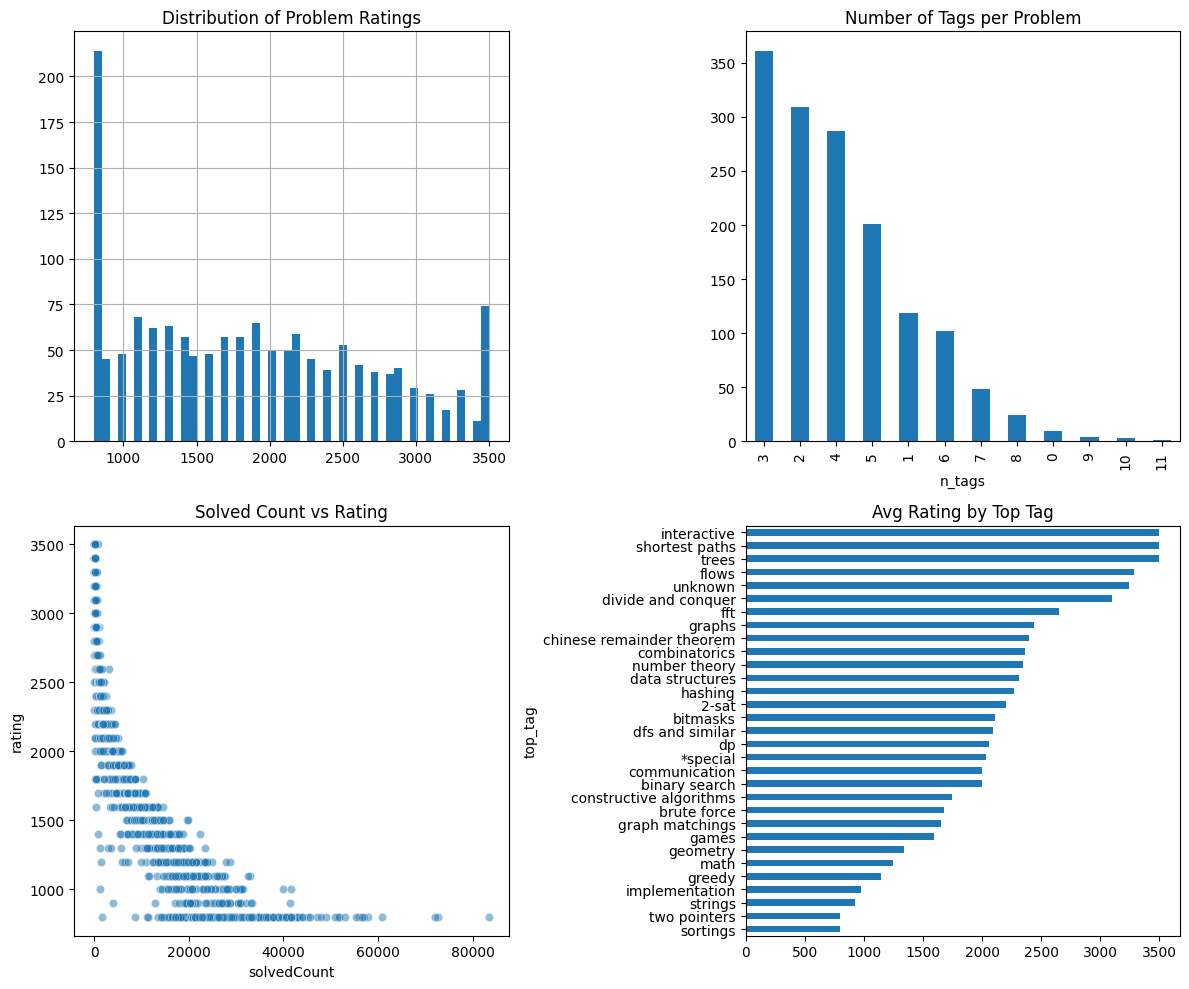

In [12]:
# 6. Визуализации
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
df['rating'].hist(bins=50, ax=axes[0, 0])
axes[0, 0].set_title('Distribution of Problem Ratings')

df['n_tags'].value_counts().plot(kind='bar', ax=axes[0, 1])
axes[0, 1].set_title('Number of Tags per Problem')

sns.scatterplot(data=df, x='solvedCount', y='rating', alpha=0.5, ax=axes[1, 0])
axes[1, 0].set_title('Solved Count vs Rating')

df.groupby('top_tag')['rating'].mean().sort_values().plot(kind='barh', ax=axes[1, 1])
axes[1, 1].set_title('Avg Rating by Top Tag')

plt.tight_layout()
plt.savefig('../report/eda_plots.png')



In [13]:
# 7. Сплит
# Проблемы из одного контеста в один сплит
contests = df['contestId'].unique()
train_contests, temp_contests = train_test_split(contests, test_size=0.3, random_state=42)
val_contests, test_contests = train_test_split(temp_contests, test_size=0.5, random_state=42)

train_df = df[df['contestId'].isin(train_contests)]
val_df = df[df['contestId'].isin(val_contests)]
test_df = df[df['contestId'].isin(test_contests)]



In [15]:
# 9. Сохраняем обработанные данные
train_df.to_csv('../data/processed/train.csv', index=False)
val_df.to_csv('../data/processed/val.csv', index=False)
test_df.to_csv('../data/processed/test.csv', index=False)

# Выделяем X и y
feature_cols = ['n_tags', 'statement_length', 'statement_words', 'has_math',
                'name_length', 'name_words', 'log_solved'] + [f'tag_{tag}' for tag in top_tags]
X_train, y_train = train_df[feature_cols], train_df['rating']
X_val, y_val = val_df[feature_cols], val_df['rating']